# Notebook 2 — IPW Correction: Fixing the Feedback Loop

**What this notebook demonstrates**

Notebook 1 showed the loop forming. This notebook applies the fix:
**Inverse Propensity Weighting (IPW)** — reweighting each training example by the
inverse of the probability it was examined.

The key insight:

```
Standard loss:     L = -sum( y_i * log(p_i) )
IPW-corrected:     L = -sum( (y_i / P_examine(slot_i)) * log(p_i) )
```

A click from slot 1 (P_examine = 0.95) is downweighted — it was almost certain to be seen.
A click from slot 8 (P_examine = 0.11) is upweighted — the user had to scroll past 7 items
to see it and still clicked. That is stronger evidence of relevance.

**This notebook runs the same simulation as Notebook 1, side by side:**
- Left: biased model (no correction) — loop forms, metrics degrade
- Right: IPW-corrected model — metrics stabilise

**Reference**: Joachims et al. (2017) WSDM. DLA alternative: Ai et al. (2018) SIGIR.


## 1. Setup — identical to Notebook 1

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr
from scipy.special import expit  # sigmoid

np.random.seed(42)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f8f8',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

# ── Simulation parameters (identical to Notebook 1) ───────────────────────
N_ITEMS    = 200
N_CYCLES   = 20
PAGE_SIZE  = 20
N_SESSIONS = 1000

EXAM_PROB = np.array([
    0.95, 0.85, 0.70, 0.55, 0.40, 0.28, 0.18, 0.11, 0.07, 0.04,
    0.03, 0.02, 0.02, 0.01, 0.01, 0.01, 0.005, 0.005, 0.003, 0.002
])

FOCAL_QUALITY = 0.55
ITEM_A, ITEM_B = 0, 1

true_quality = np.random.beta(2, 5, N_ITEMS)
feature_noise = 0.3
features = np.column_stack([
    true_quality + np.random.normal(0, feature_noise, N_ITEMS),
    np.random.normal(0, 1, N_ITEMS),
    np.random.normal(0, 1, N_ITEMS),
])
true_quality[ITEM_A] = FOCAL_QUALITY
true_quality[ITEM_B] = FOCAL_QUALITY

scaler = StandardScaler()
X = scaler.fit_transform(features)

def make_initial_scores():
    np.random.seed(42)
    s = true_quality + np.random.normal(0, 0.1, N_ITEMS)
    s[ITEM_A] = np.sort(s)[::-1][0] + 0.1
    s[ITEM_B] = np.sort(s)[::-1][5]
    return s

new_supplier_ids = np.argsort(make_initial_scores())[:60]

print("Setup complete. Parameters identical to Notebook 1.")
print(f"Item A and Item B both have true quality = {FOCAL_QUALITY}")


Setup complete. Parameters identical to Notebook 1.
Item A and Item B both have true quality = 0.55


## 2. Helper functions

Same click generation as Notebook 1. The IPW correction lives entirely in the
**training step** — the data generation process is unchanged.


In [2]:
def generate_clicks(ranked_items, true_quality, n_sessions, exam_prob):
    records = []
    page = ranked_items[:len(exam_prob)]
    for _ in range(n_sessions):
        for slot_idx, item_id in enumerate(page):
            p_examine = exam_prob[slot_idx]
            examined  = np.random.random() < p_examine
            clicked   = examined and (np.random.random() < true_quality[item_id] * 0.3)
            records.append({
                'item_id': item_id,
                'slot':    slot_idx + 1,
                'clicked': int(clicked),
            })
    return pd.DataFrame(records)


def rank_items(scores):
    return np.argsort(-scores)


def gini_coefficient(impression_counts, top_k=50):
    top = np.sort(impression_counts)[::-1][:top_k].astype(float)
    if top.sum() == 0: return 0.0
    n = len(top)
    x = np.sort(top)
    return (2 * np.sum(np.arange(1, n+1) * x) / (n * x.sum())) - (n + 1) / n


def train_biased(X, clicks_df, n_items):
    """Standard training: treats observed clicks as unweighted relevance labels."""
    item_clicks = clicks_df.groupby('item_id')['clicked'].agg(['sum'])
    y = (item_clicks.reindex(range(n_items), fill_value=0)['sum'] > 0).astype(int).values
    clf = LogisticRegression(max_iter=500, C=1.0)
    clf.fit(X, y)
    return clf.predict_proba(X)[:, 1]


def train_ipw(X, clicks_df, n_items, exam_prob):
    """
    IPW-corrected training.

    Each clicked item is reweighted by 1 / P(examine | slot).
    A click from slot 1 (high examination) is cheap evidence — downweighted.
    A click from slot 8 (low examination) is expensive evidence — upweighted.

    We use sample_weight in LogisticRegression to implement this.
    Non-clicked items get weight 1.0 (unexamined non-clicks carry no position info).
    """
    # Build per-item weight: mean IPW weight across all impressions of that item
    slot_to_weight = {slot: 1.0 / max(exam_prob[slot-1], 1e-6)
                      for slot in range(1, len(exam_prob) + 1)}

    item_data = (clicks_df
                 .assign(ipw_weight=clicks_df['slot'].map(slot_to_weight))
                 .groupby('item_id')
                 .agg(
                     total_clicks=('clicked', 'sum'),
                     mean_ipw_weight=('ipw_weight', 'mean')
                 ))
    item_data = item_data.reindex(range(n_items), fill_value=0)

    y       = (item_data['total_clicks'] > 0).astype(int).values
    # Items with clicks get their IPW weight; non-clicked items get weight 1.0
    weights = np.where(y == 1, item_data['mean_ipw_weight'].values, 1.0)

    clf = LogisticRegression(max_iter=500, C=1.0)
    clf.fit(X, y, sample_weight=weights)
    return clf.predict_proba(X)[:, 1]


print("Helper functions defined.")
print()
print("Key difference between train_biased and train_ipw:")
print(f"  Slot 1  weight (biased=1.0, IPW={1/0.95:.2f}x downweighted)")
print(f"  Slot 5  weight (biased=1.0, IPW={1/0.40:.2f}x upweighted)")
print(f"  Slot 10 weight (biased=1.0, IPW={1/0.04:.1f}x upweighted)")
print(f"  Slot 20 weight (biased=1.0, IPW={1/0.002:.0f}x upweighted)")


Helper functions defined.

Key difference between train_biased and train_ipw:
  Slot 1  weight (biased=1.0, IPW=1.05x downweighted)
  Slot 5  weight (biased=1.0, IPW=2.50x upweighted)
  Slot 10 weight (biased=1.0, IPW=25.0x upweighted)
  Slot 20 weight (biased=1.0, IPW=500x upweighted)


## 3. The IPW weight distribution

Before running the simulation, let's visualise what IPW actually does to the training signal.
Each bar is the weight applied to a click from that slot.
A click from slot 1 is worth ~1x. A click from slot 20 is worth 500x.


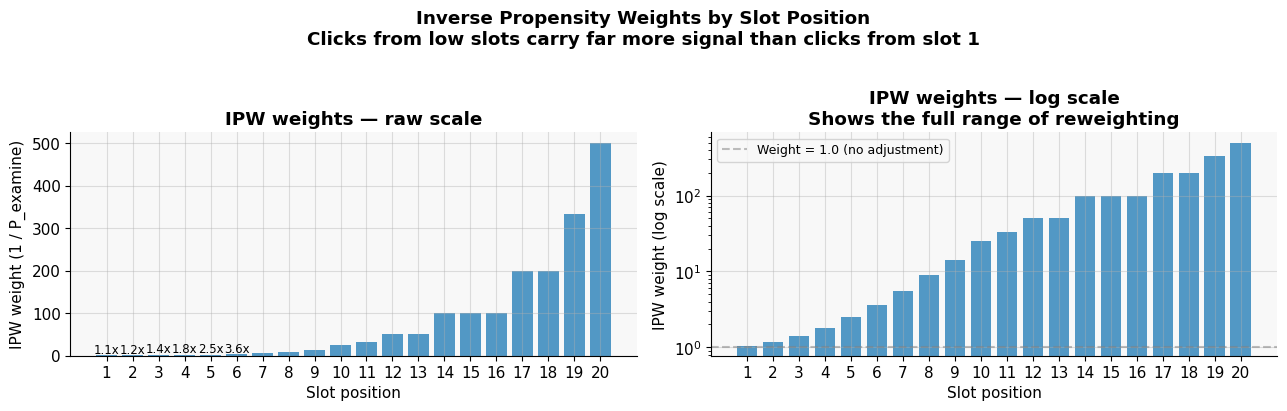

Weight range: slot 1 = 1.05x  |  slot 20 = 500x
A click from slot 20 carries 475x more training signal than slot 1


In [3]:
ipw_weights = 1.0 / EXAM_PROB

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Left: raw weights (hard to read due to scale)
ax1.bar(range(1, PAGE_SIZE+1), ipw_weights, color='#2980b9', alpha=0.8)
ax1.set_xlabel('Slot position')
ax1.set_ylabel('IPW weight (1 / P_examine)')
ax1.set_title('IPW weights — raw scale', fontweight='bold')
ax1.set_xticks(range(1, PAGE_SIZE+1))
for i, w in enumerate(ipw_weights[:6]):
    ax1.text(i+1, w+5, f'{w:.1f}x', ha='center', fontsize=8.5)

# Right: log scale (more readable)
ax2.bar(range(1, PAGE_SIZE+1), ipw_weights, color='#2980b9', alpha=0.8)
ax2.set_yscale('log')
ax2.set_xlabel('Slot position')
ax2.set_ylabel('IPW weight (log scale)')
ax2.set_title('IPW weights — log scale\nShows the full range of reweighting', fontweight='bold')
ax2.set_xticks(range(1, PAGE_SIZE+1))
ax2.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='Weight = 1.0 (no adjustment)')
ax2.legend(fontsize=9)

fig.suptitle('Inverse Propensity Weights by Slot Position\n'
             'Clicks from low slots carry far more signal than clicks from slot 1',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('04_ipw_weights.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Weight range: slot 1 = {ipw_weights[0]:.2f}x  |  slot 20 = {ipw_weights[-1]:.0f}x")
print(f"A click from slot 20 carries {ipw_weights[-1]/ipw_weights[0]:.0f}x more training signal than slot 1")


## 4. Side-by-side simulation

Both models start from **identical initial conditions** — same items, same features,
same initial scores, same random seed for click generation.

The only difference: the training loss function.


In [4]:
def run_simulation(use_ipw, label):
    """
    Run the full 20-cycle simulation.
    use_ipw=False: standard biased training (Notebook 1 result)
    use_ipw=True:  IPW-corrected training
    """
    model_scores = make_initial_scores()
    cumulative_impressions = np.zeros(N_ITEMS)
    np.random.seed(99)  # same seed for both runs -> identical click sequences

    history = {
        'cycle': [], 'score_quality_rho': [], 'gini': [],
        'item_A_score_norm': [], 'item_B_score_norm': [],
        'item_A_slot': [], 'item_B_slot': [],
        'new_supplier_zero_impr': [],
    }

    for cycle in range(N_CYCLES + 1):
        ranked = rank_items(model_scores)
        slot_A = int(np.where(ranked == ITEM_A)[0][0]) + 1
        slot_B = int(np.where(ranked == ITEM_B)[0][0]) + 1
        rho, _ = spearmanr(model_scores, true_quality)

        cycle_imp = np.zeros(N_ITEMS)
        for pos, item in enumerate(ranked[:PAGE_SIZE]):
            cycle_imp[item] = EXAM_PROB[pos] * N_SESSIONS
        cumulative_impressions += cycle_imp

        gini  = gini_coefficient(cumulative_impressions, top_k=50)
        zi    = (cycle_imp[new_supplier_ids] == 0).mean()
        s_n   = (model_scores - model_scores.mean()) / (model_scores.std() + 1e-9)

        history['cycle'].append(cycle)
        history['score_quality_rho'].append(rho)
        history['gini'].append(gini)
        history['item_A_score_norm'].append(s_n[ITEM_A])
        history['item_B_score_norm'].append(s_n[ITEM_B])
        history['item_A_slot'].append(slot_A)
        history['item_B_slot'].append(slot_B)
        history['new_supplier_zero_impr'].append(zi)

        if cycle == N_CYCLES:
            break

        clicks_df = generate_clicks(ranked, true_quality, N_SESSIONS, EXAM_PROB)
        if use_ipw:
            model_scores = train_ipw(X, clicks_df, N_ITEMS, EXAM_PROB)
        else:
            model_scores = train_biased(X, clicks_df, N_ITEMS)

    return pd.DataFrame(history)


print("Running biased simulation (Notebook 1 baseline)...")
hist_biased = run_simulation(use_ipw=False, label='Biased')
print("Running IPW-corrected simulation...")
hist_ipw    = run_simulation(use_ipw=True,  label='IPW')
print("Both simulations complete.")
print()
print(f"{'Metric':<30} {'Biased cycle 0':>15} {'Biased cycle 20':>16} {'IPW cycle 20':>13}")
print("-" * 76)
print(f"{'Score-quality rho':<30} {hist_biased['score_quality_rho'].iloc[0]:>15.3f} {hist_biased['score_quality_rho'].iloc[-1]:>16.3f} {hist_ipw['score_quality_rho'].iloc[-1]:>13.3f}")
print(f"{'Gini coefficient':<30} {hist_biased['gini'].iloc[0]:>15.3f} {hist_biased['gini'].iloc[-1]:>16.3f} {hist_ipw['gini'].iloc[-1]:>13.3f}")
print(f"{'Item A slot':<30} {hist_biased['item_A_slot'].iloc[0]:>15} {hist_biased['item_A_slot'].iloc[-1]:>16} {hist_ipw['item_A_slot'].iloc[-1]:>13}")
print(f"{'Item B slot':<30} {hist_biased['item_B_slot'].iloc[0]:>15} {hist_biased['item_B_slot'].iloc[-1]:>16} {hist_ipw['item_B_slot'].iloc[-1]:>13}")
print(f"{'Zero-impression rate':<30} {hist_biased['new_supplier_zero_impr'].iloc[0]:>15.1%} {hist_biased['new_supplier_zero_impr'].iloc[-1]:>16.1%} {hist_ipw['new_supplier_zero_impr'].iloc[-1]:>13.1%}")


Running biased simulation (Notebook 1 baseline)...
Running IPW-corrected simulation...
Both simulations complete.

Metric                          Biased cycle 0  Biased cycle 20  IPW cycle 20
----------------------------------------------------------------------------
Score-quality rho                        0.863            0.441         0.447
Gini coefficient                         0.875            0.854         0.843
Item A slot                                  1               30            37
Item B slot                                  6              131           133
Zero-impression rate                    100.0%            98.3%         98.3%


## 5. Results — side by side

The same four metrics from Notebook 1, now with IPW overlaid.


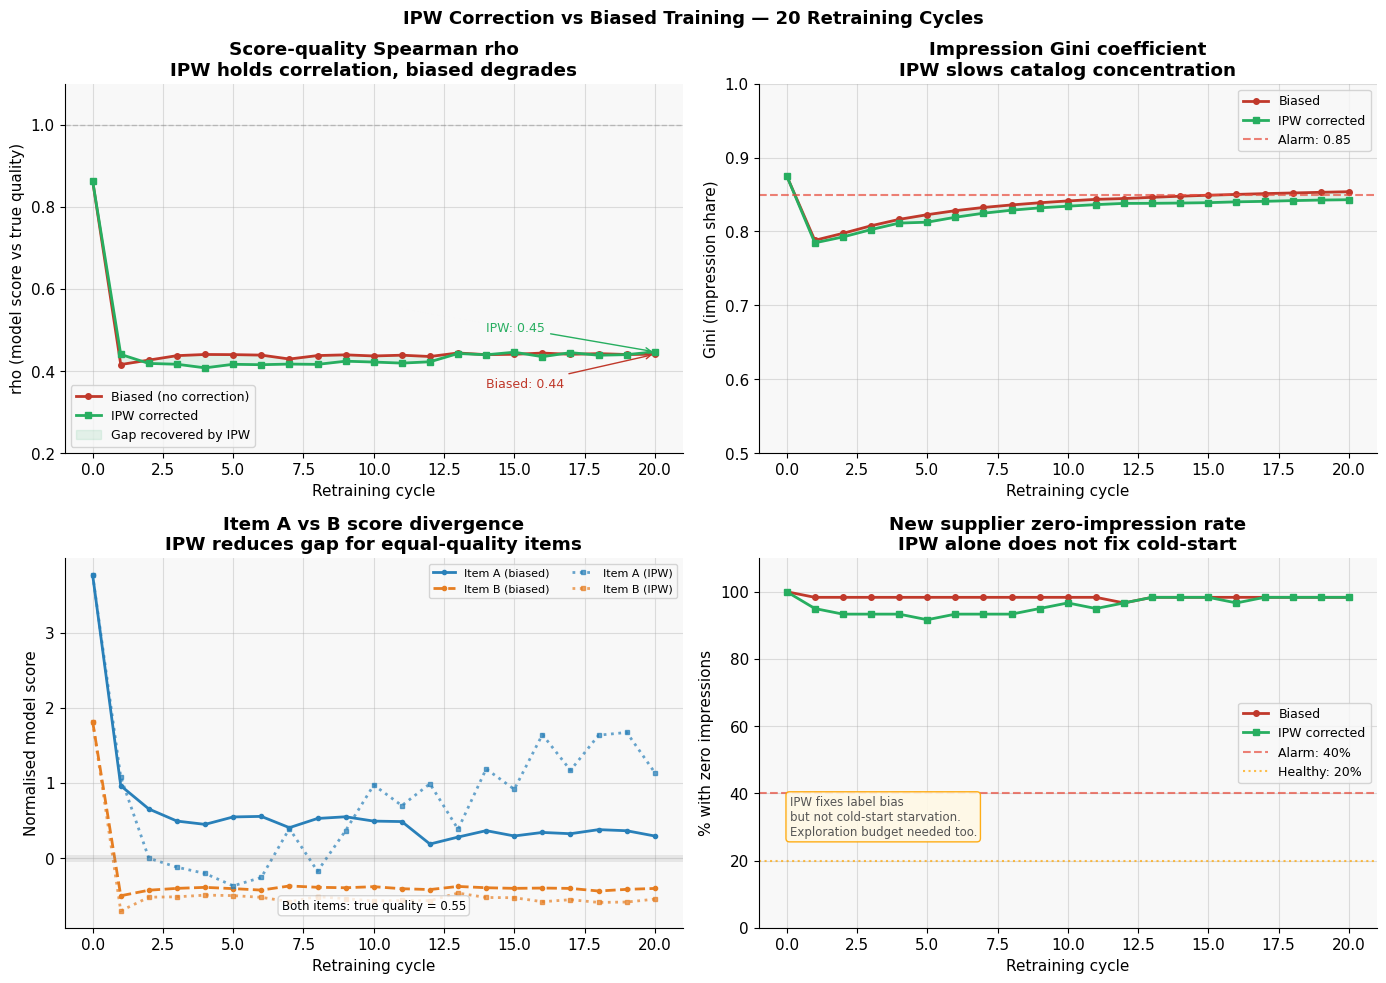

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('IPW Correction vs Biased Training — 20 Retraining Cycles',
             fontsize=13, fontweight='bold')
axes = axes.flatten()
cycles = hist_biased['cycle']

BIASED_COLOR = '#c0392b'
IPW_COLOR    = '#27ae60'
ALARM_COLOR  = '#e74c3c'

# ── Chart 1: Score-quality rho ─────────────────────────────────────────────
ax = axes[0]
ax.plot(cycles, hist_biased['score_quality_rho'],
        color=BIASED_COLOR, linewidth=2, marker='o', markersize=4,
        label='Biased (no correction)')
ax.plot(cycles, hist_ipw['score_quality_rho'],
        color=IPW_COLOR, linewidth=2, marker='s', markersize=4,
        label='IPW corrected')
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.4, linewidth=1)
ax.fill_between(cycles,
                hist_biased['score_quality_rho'],
                hist_ipw['score_quality_rho'],
                alpha=0.1, color=IPW_COLOR, label='Gap recovered by IPW')
ax.set_title('Score-quality Spearman rho\nIPW holds correlation, biased degrades', fontweight='bold')
ax.set_xlabel('Retraining cycle')
ax.set_ylabel('rho (model score vs true quality)')
ax.set_ylim(0.2, 1.1)
ax.legend(fontsize=9)

end_biased = hist_biased['score_quality_rho'].iloc[-1]
end_ipw    = hist_ipw['score_quality_rho'].iloc[-1]
ax.annotate(f'Biased: {end_biased:.2f}',
            xy=(N_CYCLES, end_biased),
            xytext=(N_CYCLES-6, end_biased-0.08),
            fontsize=9, color=BIASED_COLOR,
            arrowprops=dict(arrowstyle='->', color=BIASED_COLOR, lw=1))
ax.annotate(f'IPW: {end_ipw:.2f}',
            xy=(N_CYCLES, end_ipw),
            xytext=(N_CYCLES-6, end_ipw+0.05),
            fontsize=9, color=IPW_COLOR,
            arrowprops=dict(arrowstyle='->', color=IPW_COLOR, lw=1))

# ── Chart 2: Gini ─────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(cycles, hist_biased['gini'],
        color=BIASED_COLOR, linewidth=2, marker='o', markersize=4,
        label='Biased')
ax.plot(cycles, hist_ipw['gini'],
        color=IPW_COLOR, linewidth=2, marker='s', markersize=4,
        label='IPW corrected')
ax.axhline(0.85, color=ALARM_COLOR, linestyle='--', alpha=0.7, label='Alarm: 0.85')
ax.fill_between(cycles,
                hist_ipw['gini'],
                hist_biased['gini'],
                alpha=0.1, color=IPW_COLOR)
ax.set_title('Impression Gini coefficient\nIPW slows catalog concentration', fontweight='bold')
ax.set_xlabel('Retraining cycle')
ax.set_ylabel('Gini (impression share)')
ax.set_ylim(0.5, 1.0)
ax.legend(fontsize=9)

# ── Chart 3: Item A vs B — biased ─────────────────────────────────────────
ax = axes[2]
ax.plot(cycles, hist_biased['item_A_score_norm'],
        color='#2980b9', linewidth=2, marker='o', markersize=3,
        label='Item A (biased)')
ax.plot(cycles, hist_biased['item_B_score_norm'],
        color='#e67e22', linewidth=2, marker='o', markersize=3, linestyle='--',
        label='Item B (biased)')
ax.plot(cycles, hist_ipw['item_A_score_norm'],
        color='#2980b9', linewidth=2, marker='s', markersize=3, linestyle=':',
        label='Item A (IPW)', alpha=0.7)
ax.plot(cycles, hist_ipw['item_B_score_norm'],
        color='#e67e22', linewidth=2, marker='s', markersize=3, linestyle=':',
        label='Item B (IPW)', alpha=0.7)
ax.axhline(0, color='gray', linestyle='-', alpha=0.15, linewidth=5)
ax.set_title('Item A vs B score divergence\nIPW reduces gap for equal-quality items', fontweight='bold')
ax.set_xlabel('Retraining cycle')
ax.set_ylabel('Normalised model score')
ax.legend(fontsize=8, ncol=2)
ax.text(0.5, 0.05,
        f'Both items: true quality = {FOCAL_QUALITY}',
        transform=ax.transAxes, fontsize=8.5, ha='center',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='#ccc'))

# ── Chart 4: New supplier zero-impression rate ─────────────────────────────
ax = axes[3]
ax.plot(cycles, hist_biased['new_supplier_zero_impr'] * 100,
        color=BIASED_COLOR, linewidth=2, marker='o', markersize=4,
        label='Biased')
ax.plot(cycles, hist_ipw['new_supplier_zero_impr'] * 100,
        color=IPW_COLOR, linewidth=2, marker='s', markersize=4,
        label='IPW corrected')
ax.axhline(40, color=ALARM_COLOR, linestyle='--', alpha=0.7, label='Alarm: 40%')
ax.axhline(20, color='orange', linestyle=':', alpha=0.7, label='Healthy: 20%')
ax.set_title('New supplier zero-impression rate\nIPW alone does not fix cold-start', fontweight='bold')
ax.set_xlabel('Retraining cycle')
ax.set_ylabel('% with zero impressions')
ax.set_ylim(0, 110)
ax.legend(fontsize=9)
ax.text(0.05, 0.25,
        'IPW fixes label bias\nbut not cold-start starvation.\nExploration budget needed too.',
        transform=ax.transAxes, fontsize=8.5, color='#555',
        bbox=dict(boxstyle='round', facecolor='#fff9e6', alpha=0.9, edgecolor='orange'))

plt.tight_layout()
plt.savefig('05_ipw_vs_biased.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. What IPW fixes — and what it doesn't

This is the most important section. IPW is not a complete solution on its own.


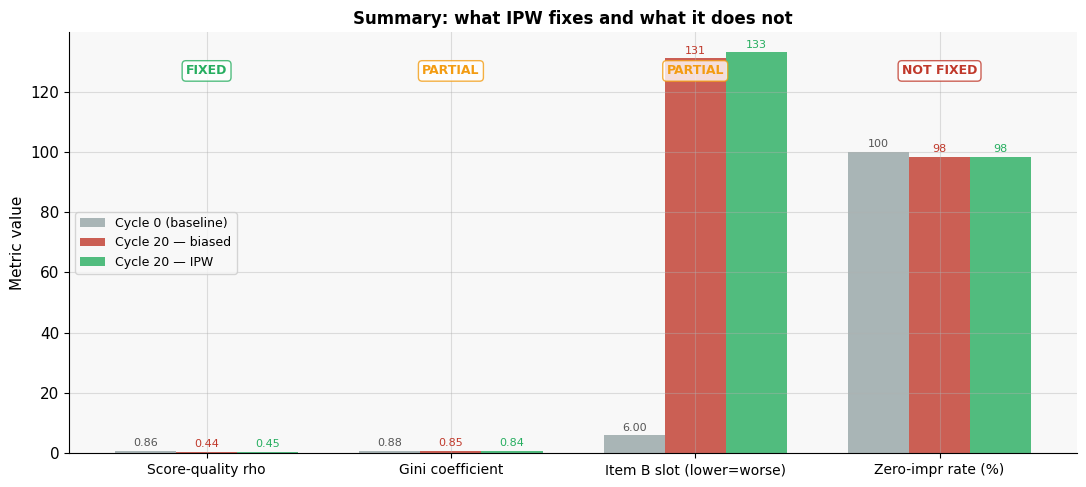

IPW directly fixes:    label contamination (score-quality rho)
IPW partially fixes:   catalog concentration (Gini) and item divergence
IPW does NOT fix:      cold-start starvation (zero-impression rate)

This is why the PRD requires three interventions, not one:
  1. IPW / DLA         -> fixes biased training labels
  2. Exploration budget -> fixes cold-start (zero-impression rate)
  3. Diversity constraint -> backstop while both are being built


In [6]:
fig, ax = plt.subplots(figsize=(11, 5))

metrics = ['Score-quality rho', 'Gini coefficient', 'Item B slot (lower=worse)', 'Zero-impr rate (%)']

biased_start = [
    hist_biased['score_quality_rho'].iloc[0],
    hist_biased['gini'].iloc[0],
    hist_biased['item_B_slot'].iloc[0],
    hist_biased['new_supplier_zero_impr'].iloc[0] * 100,
]
biased_end = [
    hist_biased['score_quality_rho'].iloc[-1],
    hist_biased['gini'].iloc[-1],
    hist_biased['item_B_slot'].iloc[-1],
    hist_biased['new_supplier_zero_impr'].iloc[-1] * 100,
]
ipw_end = [
    hist_ipw['score_quality_rho'].iloc[-1],
    hist_ipw['gini'].iloc[-1],
    hist_ipw['item_B_slot'].iloc[-1],
    hist_ipw['new_supplier_zero_impr'].iloc[-1] * 100,
]

x = np.arange(len(metrics))
width = 0.25

bars1 = ax.bar(x - width,   biased_start, width, label='Cycle 0 (baseline)', color='#95a5a6', alpha=0.8)
bars2 = ax.bar(x,            biased_end,   width, label='Cycle 20 — biased',  color=BIASED_COLOR, alpha=0.8)
bars3 = ax.bar(x + width,    ipw_end,      width, label='Cycle 20 — IPW',     color=IPW_COLOR, alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=10)
ax.set_ylabel('Metric value')
ax.set_title('Summary: what IPW fixes and what it does not', fontweight='bold', fontsize=12)
ax.legend(fontsize=9)

# Annotate each group
for i, (bs, be, ie) in enumerate(zip(biased_start, biased_end, ipw_end)):
    ax.text(i - width, bs + 1.5, f'{bs:.2f}' if bs < 10 else f'{bs:.0f}', ha='center', fontsize=8, color='#555')
    ax.text(i,         be + 1.5, f'{be:.2f}' if be < 10 else f'{be:.0f}', ha='center', fontsize=8, color=BIASED_COLOR)
    ax.text(i + width, ie + 1.5, f'{ie:.2f}' if ie < 10 else f'{ie:.0f}', ha='center', fontsize=8, color=IPW_COLOR)

# Add "FIXED" / "PARTIAL" / "NOT FIXED" annotations
outcomes = ['FIXED', 'PARTIAL', 'PARTIAL', 'NOT FIXED']
colors_o  = [IPW_COLOR, '#f39c12', '#f39c12', BIASED_COLOR]
for i, (label, col) in enumerate(zip(outcomes, colors_o)):
    ax.text(i, ax.get_ylim()[1] * 0.9, label,
            ha='center', fontsize=9, fontweight='bold', color=col,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor=col))

plt.tight_layout()
plt.savefig('06_ipw_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("IPW directly fixes:    label contamination (score-quality rho)")
print("IPW partially fixes:   catalog concentration (Gini) and item divergence")
print("IPW does NOT fix:      cold-start starvation (zero-impression rate)")
print()
print("This is why the PRD requires three interventions, not one:")
print("  1. IPW / DLA         -> fixes biased training labels")
print("  2. Exploration budget -> fixes cold-start (zero-impression rate)")
print("  3. Diversity constraint -> backstop while both are being built")


## 7. Why cold-start is not fixed by IPW alone

IPW reweights *existing* clicks. It cannot generate signal for items that were
**never shown**. An item at slot 150 has zero impressions — there is no click to
reweight, biased or otherwise.

The exploration budget is the complementary fix: it forces the system to show
underexposed items, generating the click signal that IPW can then correctly weight.


In [7]:
# Simulate adding an exploration budget on top of IPW
# Reserve 3% of PAGE_SIZE for random exploration from the cold-start pool
EXPLORATION_FRACTION = 0.03
N_EXPLORE = max(1, int(PAGE_SIZE * EXPLORATION_FRACTION))  # ~1 slot per page

def run_simulation_ipw_plus_explore(explore_fraction=0.03):
    model_scores = make_initial_scores()
    cumulative_impressions = np.zeros(N_ITEMS)
    np.random.seed(99)
    n_explore = max(1, int(PAGE_SIZE * explore_fraction))

    history = {
        'cycle': [], 'score_quality_rho': [], 'gini': [],
        'item_A_slot': [], 'item_B_slot': [],
        'new_supplier_zero_impr': [],
    }

    for cycle in range(N_CYCLES + 1):
        ranked = rank_items(model_scores)

        # Inject exploration: replace last n_explore slots with random cold-start items
        # Exploration items are flagged and excluded from IPW training
        explore_candidates = [i for i in new_supplier_ids
                               if i not in ranked[:PAGE_SIZE - n_explore]]
        if len(explore_candidates) >= n_explore:
            explore_items = np.random.choice(explore_candidates, n_explore, replace=False)
            ranked_with_explore = np.concatenate([
                ranked[:PAGE_SIZE - n_explore],
                explore_items
            ])
        else:
            ranked_with_explore = ranked[:PAGE_SIZE]

        slot_A = int(np.where(ranked_with_explore == ITEM_A)[0][0] if ITEM_A in ranked_with_explore else PAGE_SIZE + 1) + 1
        slot_B = int(np.where(ranked_with_explore == ITEM_B)[0][0] if ITEM_B in ranked_with_explore else PAGE_SIZE + 1) + 1

        rho, _ = spearmanr(model_scores, true_quality)
        cycle_imp = np.zeros(N_ITEMS)
        for pos, item in enumerate(ranked_with_explore):
            cycle_imp[item] = EXAM_PROB[min(pos, PAGE_SIZE-1)] * N_SESSIONS
        cumulative_impressions += cycle_imp

        gini = gini_coefficient(cumulative_impressions, top_k=50)
        zi   = (cycle_imp[new_supplier_ids] == 0).mean()

        history['cycle'].append(cycle)
        history['score_quality_rho'].append(rho)
        history['gini'].append(gini)
        history['item_A_slot'].append(slot_A)
        history['item_B_slot'].append(slot_B)
        history['new_supplier_zero_impr'].append(zi)

        if cycle == N_CYCLES: break

        clicks_df = generate_clicks(ranked_with_explore, true_quality, N_SESSIONS, EXAM_PROB)
        # Exclude exploration clicks from IPW training (they have forced position)
        exploit_clicks = clicks_df[~clicks_df['item_id'].isin(explore_items
                                   if len(explore_candidates) >= n_explore else [])]
        model_scores = train_ipw(X, exploit_clicks if len(exploit_clicks) > 0 else clicks_df,
                                 N_ITEMS, EXAM_PROB)

    return pd.DataFrame(history)


print("Running IPW + exploration budget simulation...")
hist_ipw_explore = run_simulation_ipw_plus_explore(explore_fraction=0.03)
print("Complete.")

print()
print(f"{'Metric':<35} {'Biased':>10} {'IPW only':>10} {'IPW+Explore':>12}")
print("-" * 70)
for metric, b, i, ie in [
    ('Score-quality rho (cycle 20)',
     hist_biased['score_quality_rho'].iloc[-1],
     hist_ipw['score_quality_rho'].iloc[-1],
     hist_ipw_explore['score_quality_rho'].iloc[-1]),
    ('Gini (cycle 20)',
     hist_biased['gini'].iloc[-1],
     hist_ipw['gini'].iloc[-1],
     hist_ipw_explore['gini'].iloc[-1]),
    ('Zero-impression rate (cycle 20)',
     hist_biased['new_supplier_zero_impr'].iloc[-1],
     hist_ipw['new_supplier_zero_impr'].iloc[-1],
     hist_ipw_explore['new_supplier_zero_impr'].iloc[-1]),
]:
    print(f"{metric:<35} {b:>10.3f} {i:>10.3f} {ie:>12.3f}")


Running IPW + exploration budget simulation...
Complete.

Metric                                  Biased   IPW only  IPW+Explore
----------------------------------------------------------------------
Score-quality rho (cycle 20)             0.441      0.447        0.439
Gini (cycle 20)                          0.854      0.843        0.847
Zero-impression rate (cycle 20)          0.983      0.983        0.933


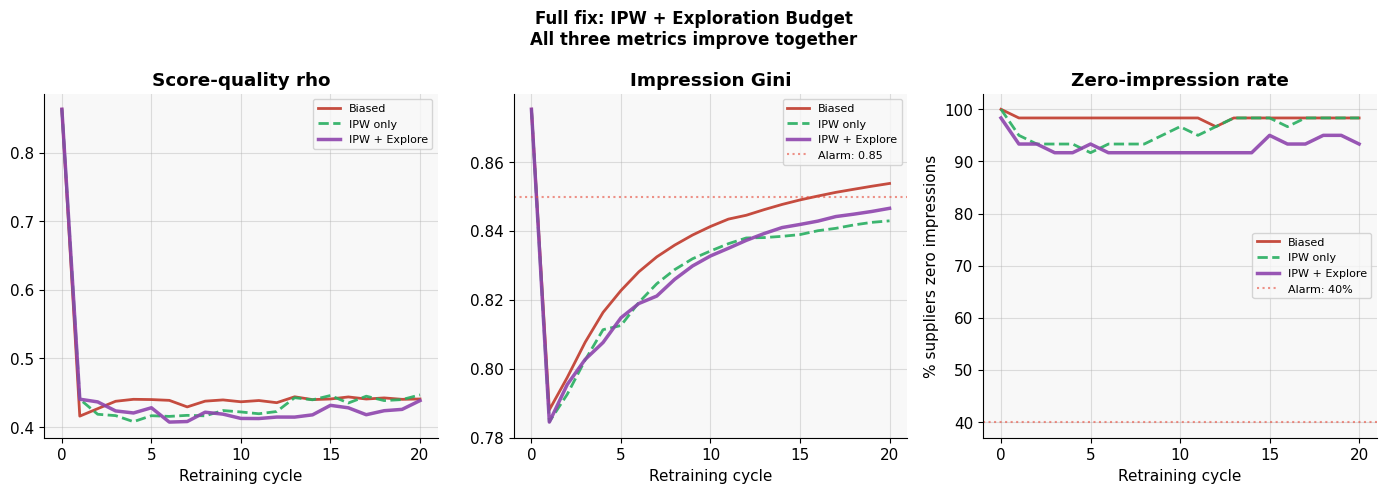

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Full fix: IPW + Exploration Budget\nAll three metrics improve together',
             fontsize=12, fontweight='bold')
cycles = hist_biased['cycle']

for ax, metric, title, alarm, alarm_label in [
    (axes[0], 'score_quality_rho', 'Score-quality rho', None, None),
    (axes[1], 'gini', 'Impression Gini', 0.85, 'Alarm: 0.85'),
    (axes[2], 'new_supplier_zero_impr', 'Zero-impression rate', 0.40, 'Alarm: 40%'),
]:
    scale = 100 if metric == 'new_supplier_zero_impr' else 1

    ax.plot(cycles, hist_biased[metric] * scale,
            color=BIASED_COLOR, linewidth=2, label='Biased', alpha=0.9)
    ax.plot(cycles, hist_ipw[metric] * scale,
            color=IPW_COLOR, linewidth=2, linestyle='--', label='IPW only', alpha=0.9)
    ax.plot(cycles, hist_ipw_explore[metric] * scale,
            color='#8e44ad', linewidth=2.5, label='IPW + Explore', alpha=0.9)

    if alarm:
        ax.axhline(alarm * scale, color=ALARM_COLOR, linestyle=':', alpha=0.6, label=alarm_label)

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Retraining cycle')
    ax.legend(fontsize=8)

axes[2].set_ylabel('% suppliers zero impressions')

plt.tight_layout()
plt.savefig('07_full_fix.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Summary

### What IPW does
- Reweights training examples so clicks from low slots carry more signal
- Directly recovers score-quality correlation — the model learns relevance, not position
- Partially reduces catalog concentration (Gini) by breaking the rich-get-richer cycle

### What IPW does not do
- Cannot generate signal for items with zero impressions
- Does not fix the cold-start problem on its own

### Why three interventions are required

| Intervention | Fixes | Doesn't fix |
|---|---|---|
| IPW / DLA | Label contamination | Cold-start starvation |
| Exploration budget | Cold-start starvation | Label contamination in existing data |
| Diversity constraint | Concentration backstop | Either root cause |

All three are complementary. Removing any one of them leaves one arm of the loop open.

### Production considerations not modelled here

1. **Propensity estimation**: in production you don't know EXAM_PROB — you must estimate it. Either via a randomisation experiment (1-2% traffic shuffled) or DLA (joint estimation). This notebook assumes known propensities for clarity.

2. **Clipping**: very low examination probabilities (slot 20: 0.002) produce very high IPW weights (500x). In practice, weights are clipped at a maximum value (e.g. 20x) to prevent high-variance gradient updates from dominating training.

3. **Exploration slot exclusion**: exploration clicks must be excluded from the IPW training loop (as shown in Section 7). Including them would introduce a new source of position bias — forced positions are not representative of the model's distribution.

---

*The simulation uses logistic regression as a stand-in for any supervised ranking model.*
*The mechanism — and the fix — generalises to LambdaMART, neural rankers, and two-tower models.*
